In [1]:
project_root = "/home/krzysztof/studia/magisterka/time-series-invariance"

import os
subdir = ""
os.chdir(os.path.join(project_root, subdir))


In [2]:
from src.data_generation.simple_data_generation import shift_time_series, shrunk_time_series
from notebooks.evaluations.helpers import (
        apply_embedding_function_shrunk,
        apply_embedding_function_shifts,
        load_dataset,
        load_distortions,
        test_embeddings_quality
    )

In [25]:
data_dir = "data/datasets"
dataset_names = [name[:-4] for name in os.listdir(data_dir)]

models_path = "notebooks/ts2vec/models"
processed_datasets = set()
for result_name in os.listdir(models_path):
    dataset_name = result_name.split("__")[0]
    processed_datasets.add(dataset_name)

usable_datasets = [dataset_name for dataset_name in dataset_names if dataset_name not in processed_datasets]
usable_datasets

['OSULeaf',
 'Adiac',
 'Fish',
 'MedicalImages',
 'Wafer',
 'SwedishLeaf',
 'FacesUCR',
 'SyntheticControl',
 'FaceFour',
 'Trace',
 'Beef',
 'GunPoint',
 'TwoPatterns',
 'Coffee',
 'OliveOil',
 'ECG200']

In [ ]:
subdir = "ts2vec"
os.chdir(os.path.join(project_root, subdir))

from ts2vec import TS2VecTS2Vec

print("Model loaded successfully!")

subdir = ""
os.chdir(os.path.join(project_root, subdir))

Model loaded successfully!


In [5]:
import re
pattern = re.compile(r"(.+)__test_run_(\d{8})_(\d{6})")

model_paths = {}
model_dir = "ts2vec/training"
for name in os.listdir(model_dir):
    match = pattern.match(name)
    if match:
        dataset_name = match.group(1)
        date = float(match.group(2)) + float(match.group(3))/1e6
        if date > model_paths.get(dataset_name, {}).get("date", 0):
            model_paths[dataset_name] = {
                "date": date,
                "path": os.path.join(model_dir, name, "model.pkl")
            }
model_paths

{'TwoPatterns': {'date': 20260316.121011,
  'path': 'ts2vec/training/TwoPatterns__test_run_20260316_121011/model.pkl'},
 'Beef': {'date': 20260316.120934,
  'path': 'ts2vec/training/Beef__test_run_20260316_120934/model.pkl'},
 'GunPoint': {'date': 20260316.120947,
  'path': 'ts2vec/training/GunPoint__test_run_20260316_120947/model.pkl'},
 'CBF': {'date': 20260316.120325,
  'path': 'ts2vec/training/CBF__test_run_20260316_120325/model.pkl'},
 'Adiac': {'date': 20260316.120555,
  'path': 'ts2vec/training/Adiac__test_run_20260316_120555/model.pkl'},
 'OSULeaf': {'date': 20260316.120349,
  'path': 'ts2vec/training/OSULeaf__test_run_20260316_120349/model.pkl'},
 'ECG200': {'date': 20260316.1211,
  'path': 'ts2vec/training/ECG200__test_run_20260316_121100/model.pkl'},
 'Trace': {'date': 20260316.120911,
  'path': 'ts2vec/training/Trace__test_run_20260316_120911/model.pkl'},
 'Coffee': {'date': 20260316.121035,
  'path': 'ts2vec/training/Coffee__test_run_20260316_121035/model.pkl'},
 'OliveOil

In [6]:
import torch
from torch import nn
import torch.nn.functional as F
import numpy as np

class AttnPool(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.attn = nn.Linear(d, 1)

    def forward(self, x):  # (B, T, D)
        w = self.attn(x).squeeze(-1)      # (B, T)
        w = torch.softmax(w, dim=1)
        return torch.sum(x * w.unsqueeze(-1), dim=1)

def get_ts2vec_embeddings(model: TS2Vec, pool: AttnPool, x):
    if isinstance(x, np.ndarray):
        x = torch.from_numpy(x).float()
    if x.ndim == 1:
        x = x.unsqueeze(0).unsqueeze(2)
    if x.ndim == 2:
        x = x.unsqueeze(0)
    out: torch.Tensor = model.net(x.to(model.device, non_blocking=True), None)
    out = pool(out)
    return out

In [7]:
import torch
import torch.nn.functional as F

def contrastive_loss(z1, z2, temperature=0.2):
    """
    z1, z2: (B, d)
    """
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)

    B = z1.size(0)

    z = torch.cat([z1, z2], dim=0)  # (2B, d)

    similarity = torch.matmul(z, z.T)  # (2B, 2B)
    similarity /= temperature

    # remove self-similarity
    mask = torch.eye(2 * B, dtype=torch.bool, device=z.device)
    similarity.masked_fill_(mask, -1e9)

    # labels
    labels = torch.arange(2 * B, device=z.device)
    labels = (labels + B) % (2 * B)

    loss = F.cross_entropy(similarity, labels)

    return loss

In [15]:
import numpy as np


def train_model(dataset_name, all_models, k=5, patience=10, epochs=100):
    data = load_dataset(dataset_name)
    print(f"data shape: {data.shape}")
    indexes_order = np.arange(data.shape[0])
    np.random.shuffle(indexes_order)
    train_folds = []
    validation_folds = []
    test_folds = []
    for fold in range(k):
        test_indices = indexes_order[fold::k]
        validation_indices = indexes_order[(fold+1)%k::k]
        train_indices = np.setdiff1d(indexes_order, np.concatenate([test_indices, validation_indices]))
        train_folds.append(train_indices)
        validation_folds.append(validation_indices)
        test_folds.append(test_indices)
    

    all_shift_val_losses = []
    all_shrink_val_losses = []
    all_shift_train_losses = []
    all_shrink_train_losses = []

    sequence_length = data.shape[1]
    for j in range(k):
        model_path = model_paths[dataset_name]["path"]
        model = TS2Vec(input_dims=1, device='cpu', output_dims=320)
        model.load(model_path)

        pool = AttnPool(320)
        pool.to(model.device)

        optimizer = torch.optim.Adam(list(model.net.parameters()) + list(pool.parameters()), lr=1e-4)


        best_val_loss = float('inf')
        no_improvement = 0
        shift_val_losses = []
        shrink_val_losses = []
        shift_train_losses = []
        shrink_train_losses = []
        for i in range(epochs):
            print("-" * 50)
            print(f"Fold {j+1}/{k}")
            print(f"Epoch {i+1}/{epochs}")

            random_shift = 0
            while random_shift == 0:
                random_shift = np.random.randint(-sequence_length//4, sequence_length//4)
            if random_shift < 0:
                shifted_data = data[:, -random_shift:]
            else:
                shifted_data = data[:, :-random_shift]

            random_shrink = np.random.random() / 4 + 0.75

            original_data = torch.from_numpy(data).float().unsqueeze(2)
            shifted_data = torch.from_numpy(shifted_data).float().unsqueeze(2)
            shrunk_data = F.interpolate(
                original_data.transpose(1, 2),
                scale_factor=random_shrink,
                mode='linear',
                align_corners=False
            ).transpose(1, 2)

            original_embeddings_train = get_ts2vec_embeddings(model, pool, original_data[train_folds[j]])
            shifted_embeddings_train = get_ts2vec_embeddings(model, pool, shifted_data[train_folds[j]])
            shrunk_embeddings_train = get_ts2vec_embeddings(model, pool, shrunk_data[train_folds[j]])

            optimizer.zero_grad()
            loss1 = contrastive_loss(original_embeddings_train, shifted_embeddings_train)
            loss2 = contrastive_loss(original_embeddings_train, shrunk_embeddings_train)
            print(f"Shifted loss: {loss1.item():.4f}")
            print(f"Shrunk loss: {loss2.item():.4f}")
            shift_train_losses.append(loss1.item())
            shrink_train_losses.append(loss2.item())

            loss = loss1 + loss2
            loss.backward()
            optimizer.step()

            with torch.no_grad():
                original_embeddings_val = get_ts2vec_embeddings(model, pool, original_data[validation_folds[j]])
                shifted_embeddings_val = get_ts2vec_embeddings(model, pool, shifted_data[validation_folds[j]])
                shrunk_embeddings_val = get_ts2vec_embeddings(model, pool, shrunk_data[validation_folds[j]])

                val_loss1 = contrastive_loss(original_embeddings_val, shifted_embeddings_val)
                val_loss2 = contrastive_loss(original_embeddings_val, shrunk_embeddings_val)
                print(f"Validation Shifted loss: {val_loss1.item():.4f}")
                print(f"Validation Shrunk loss: {val_loss2.item():.4f}")
                shift_val_losses.append(val_loss1.item())
                shrink_val_losses.append(val_loss2.item())

                val_loss = val_loss1 + val_loss2
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    no_improvement = 0
                else:
                    no_improvement += 1
                    if no_improvement >= patience:
                        print("Early stopping")
                        break
            
        all_shift_val_losses.append(shift_val_losses)
        all_shrink_val_losses.append(shrink_val_losses)
        all_shift_train_losses.append(shift_train_losses)
        all_shrink_train_losses.append(shrink_train_losses)

        models_path = f"notebooks/ts2vec/models/{dataset_name}__test_run_{j}"

        os.makedirs(models_path, exist_ok=True)
        model.save(f"{models_path}/model.pkl")
        torch.save(pool.state_dict(), f"{models_path}/pool.pkl")
        np.save(f"{models_path}/test_indices.npy", test_folds[j])
        
        all_models[dataset_name].append((j, models_path))


    return (
        all_shift_val_losses,
        all_shrink_val_losses,
        all_shift_train_losses,
        all_shrink_train_losses,
        all_models
    )

In [9]:
import json
import pandas as pd

def get_result_df(all_results, metric_name):
    data_for_df = {}

    for method, datasets in all_results.items():
        row = {}
        for dataset, metrics in datasets.items():
            row[dataset] = metrics[metric_name]
        data_for_df[method] = row

    df = pd.DataFrame.from_dict(data_for_df, orient='index')

    return df

all_results_shrink_path = "results/shrink_results.json"
if os.path.exists(all_results_shrink_path):
    with open(all_results_shrink_path, "r") as f:
        all_results_shrink = json.load(f)


all_results_shift_path = "results/shift_results.json"
if os.path.exists(all_results_shift_path):
    with open(all_results_shift_path, "r") as f:
        all_results_shift = json.load(f)


CBF
data shape: (500, 128)
--------------------------------------------------
Fold 1/5
Epoch 1/100
Shifted loss: 6.3277
Shrunk loss: 6.2749
Validation Shifted loss: 5.1992
Validation Shrunk loss: 5.1618
--------------------------------------------------
Fold 1/5
Epoch 2/100
Shifted loss: 6.2586
Shrunk loss: 6.2576
Validation Shifted loss: 5.1358
Validation Shrunk loss: 5.1338
--------------------------------------------------
Fold 1/5
Epoch 3/100
Shifted loss: 6.2200
Shrunk loss: 6.2276
Validation Shifted loss: 5.1086
Validation Shrunk loss: 5.1112
--------------------------------------------------
Fold 1/5
Epoch 4/100
Shifted loss: 6.3166
Shrunk loss: 6.2230
Validation Shifted loss: 5.2046
Validation Shrunk loss: 5.0977
--------------------------------------------------
Fold 1/5
Epoch 5/100
Shifted loss: 6.2057
Shrunk loss: 6.1823
Validation Shifted loss: 5.0539
Validation Shrunk loss: 5.0370
--------------------------------------------------
Fold 1/5
Epoch 6/100
Shifted loss: 6.1443


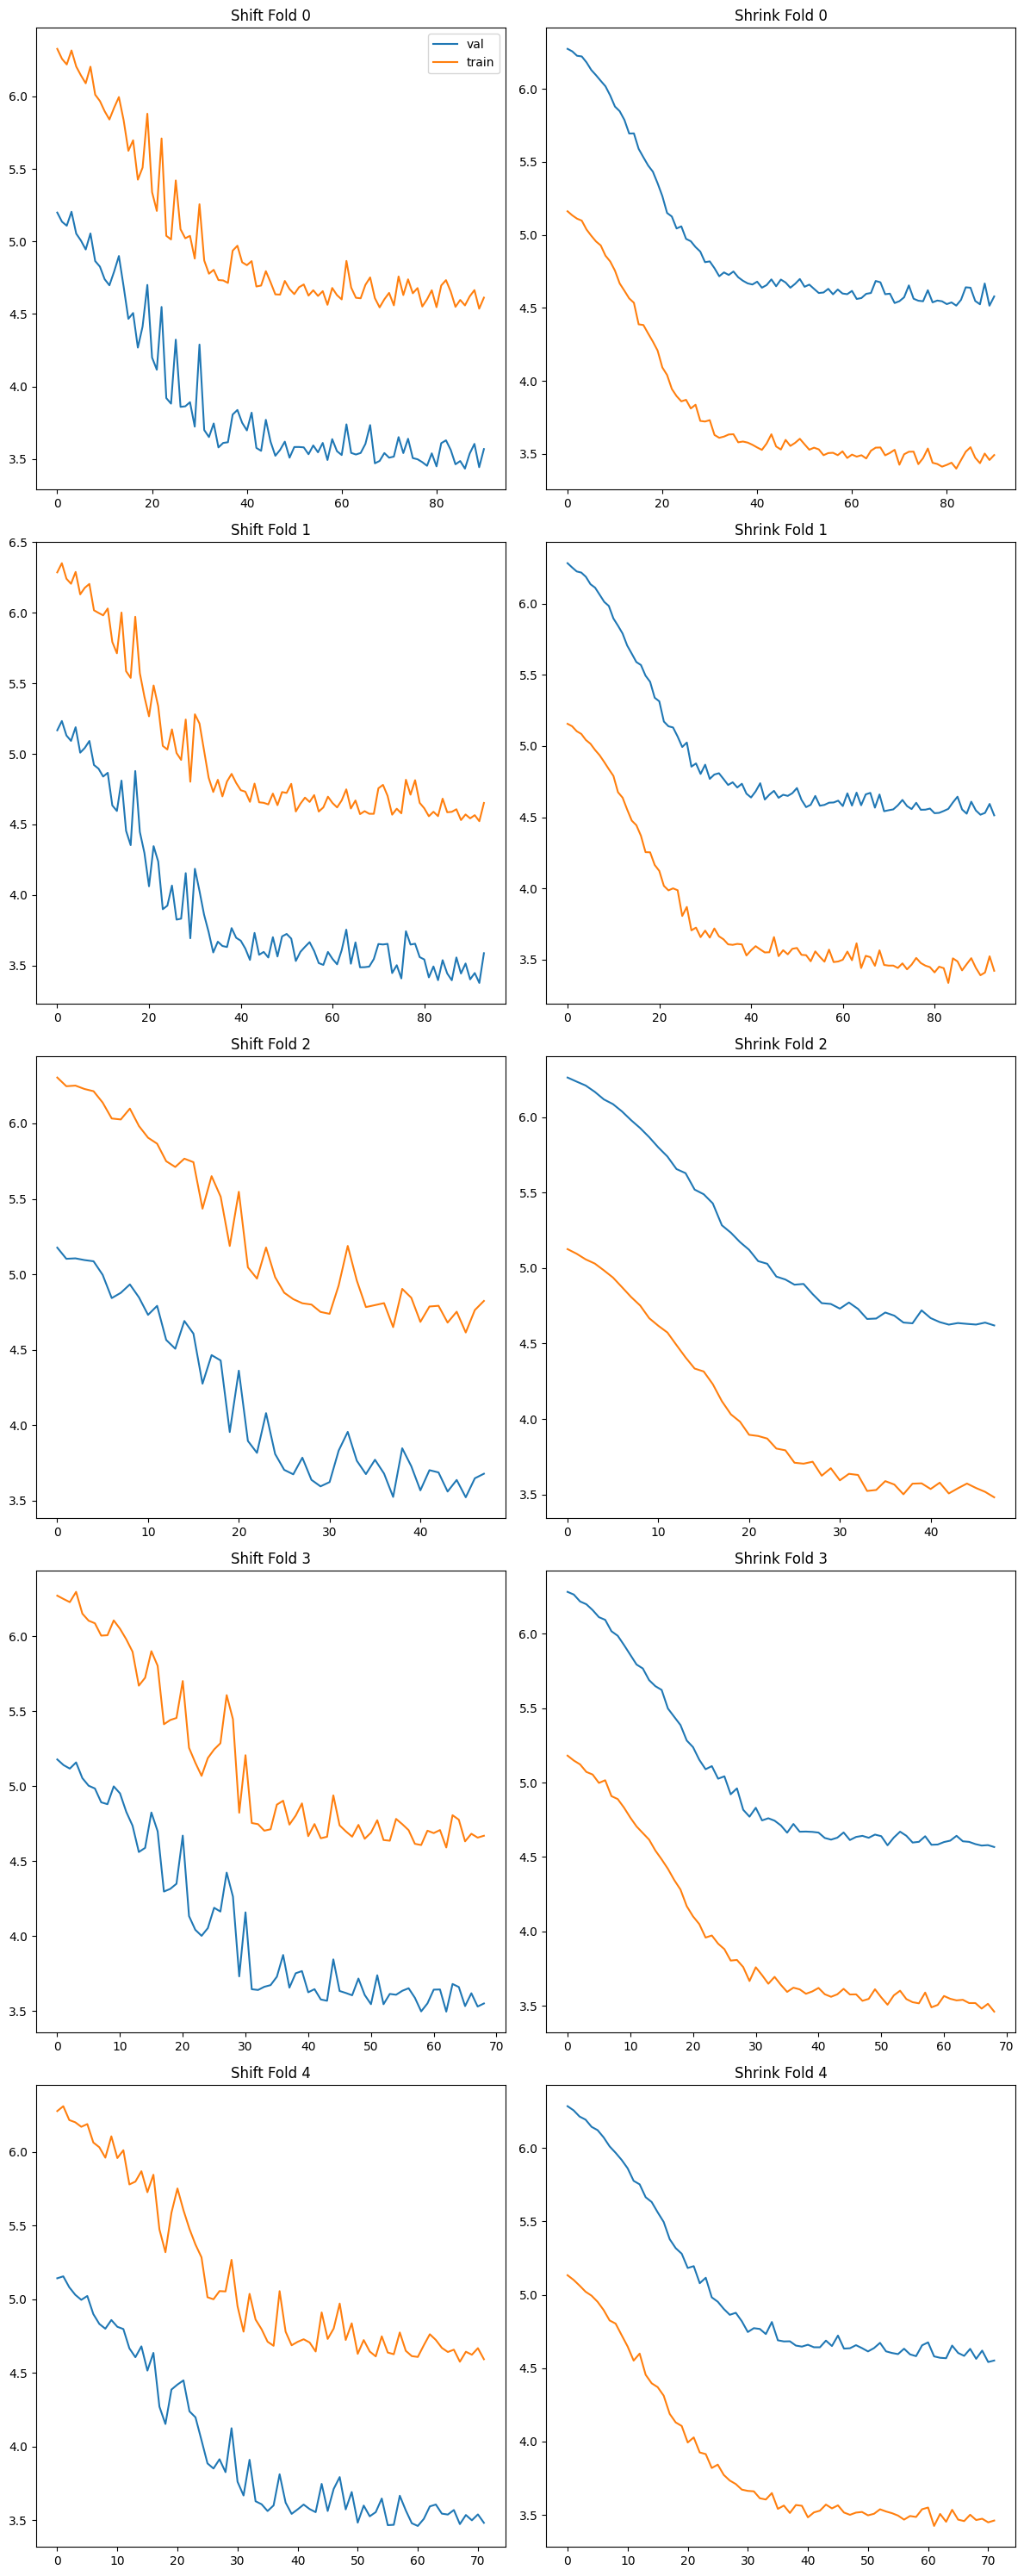

In [16]:
from collections import defaultdict
from matplotlib import pyplot as plt
import numpy as np

k = 5
patience = 10
epochs = 100
all_models = defaultdict(list)

for dataset_name in dataset_names:
    print(dataset_name)

    (
        all_shift_val_losses,
        all_shrink_val_losses,
        all_shift_train_losses,
        all_shrink_train_losses,
        all_models
    ) = train_model(dataset_name, all_models, epochs=epochs)

    fig, ax = plt.subplots(k, 2, figsize=(12, 30))

    for i in range(min(k, len(all_shift_train_losses))):
        ax[i, 0].plot(all_shift_val_losses[i], label="val")
        ax[i, 0].plot(all_shift_train_losses[i], label="train")
        ax[i, 0].set_title(f"Shift Fold {i}")

        ax[i, 1].plot(all_shrink_train_losses[i], label="train")
        ax[i, 1].plot(all_shrink_val_losses[i], label="val")
        ax[i, 1].set_title(f"Shrink Fold {i}")

    ax[0, 0].legend()

    plt.tight_layout()
    plt.show()
                

data shape: (500, 128)
Global cos similarity: 0.020432142540812492, Local cos similarity: 0.9402585029602051
Silhouette score cosine: -0.20428694784641266
Silhouette score euclidean: -0.1108182892203331
Fisher Discriminant Ratio (FDR): 2.89787929262608
Cohen's d: 2.4074381789055685


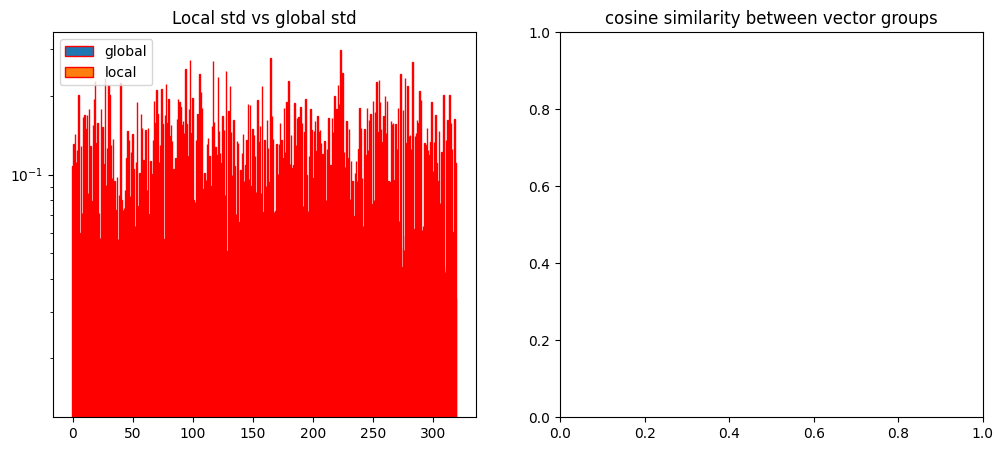

In [17]:
distortion_type = "shrink"
all_results_shrink['ts2vec_ah'] = {}
for dataset_name in dataset_names:
    data = load_dataset(dataset_name)
    print(f"data shape: {data.shape}")
    random_shrinks = load_distortions(dataset_name, distortion_type)

    all_embeddings = []
    for _, model_paths in all_models[dataset_name]:
        model = TS2Vec(input_dims=1, device='cpu', output_dims=320)
        model.load(f"{model_paths}/model.pkl")
        pool = AttnPool(320)
        pool.load_state_dict(torch.load(f"{model_paths}/pool.pkl"))
        test_indices = np.load(f"{model_paths}/test_indices.npy")

        test_data = data[test_indices]
        embeddings = apply_embedding_function_shrunk(test_data, lambda x: get_ts2vec_embeddings(model, pool, x), random_shrinks)
        all_embeddings.extend(
            [v.squeeze(0).detach().cpu().numpy() for v in e]
            for e in embeddings
        )
    all_embeddings = np.array(all_embeddings)
    _, evaluation_results = test_embeddings_quality(all_embeddings, dataset_name)
    all_results_shrink['ts2vec_ah'][dataset_name] = evaluation_results

data shape: (500, 128)
Global cos similarity: 0.023969857022166252, Local cos similarity: 0.9179756045341492
Silhouette score cosine: -0.2702254354953766
Silhouette score euclidean: -0.1462315320968628
Fisher Discriminant Ratio (FDR): 2.6905449129964003
Cohen's d: 2.319717617726951


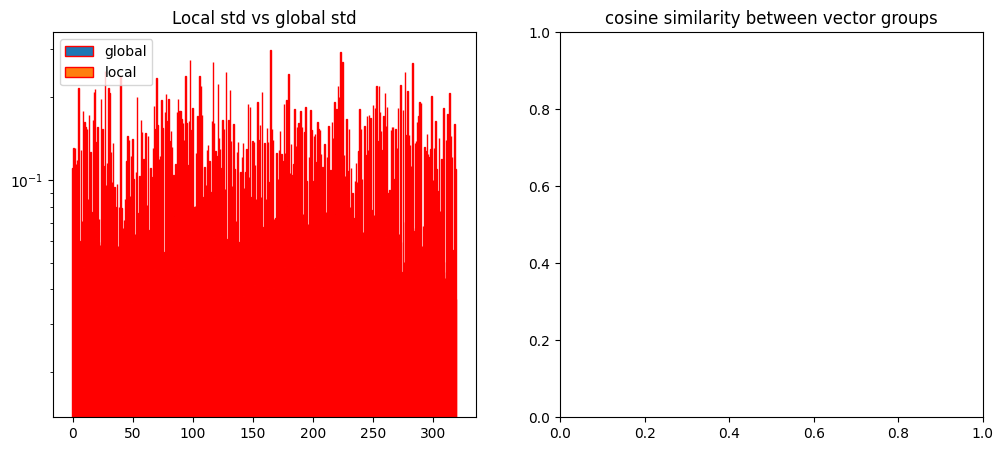

In [19]:
distortion_type = "shift"
all_results_shift['ts2vec_ah'] = {}
for dataset_name in dataset_names:
    data = load_dataset(dataset_name)
    print(f"data shape: {data.shape}")
    random_shifts = load_distortions(dataset_name, distortion_type)

    all_embeddings = []
    for _, model_paths in all_models[dataset_name]:
        model = TS2Vec(input_dims=1, device='cpu', output_dims=320)
        model.load(f"{model_paths}/model.pkl")
        pool = AttnPool(320)
        pool.load_state_dict(torch.load(f"{model_paths}/pool.pkl"))
        test_indices = np.load(f"{model_paths}/test_indices.npy")
        
        test_data = data[test_indices]
        embeddings = apply_embedding_function_shifts(test_data, lambda x: get_ts2vec_embeddings(model, pool, x), random_shifts)
        all_embeddings.extend(
            [v.squeeze(0).detach().cpu().numpy() for v in e]
            for e in embeddings
        )
    all_embeddings = np.array(all_embeddings)
    _, evaluation_results = test_embeddings_quality(all_embeddings, dataset_name)
    all_results_shift['ts2vec_ah'][dataset_name] = evaluation_results

In [20]:
all_results_shrink_path_new = "results/shrink_results_new.json"
all_results_shift_path_new = "results/shift_results_new.json"
with open(all_results_shrink_path_new, "w") as f:
    json.dump(all_results_shrink, f, indent=4)
with open(all_results_shift_path_new, "w") as f:
    json.dump(all_results_shift, f, indent=4)

TypeError: Object of type float32 is not JSON serializable

In [22]:
fdr_shrink = get_result_df(all_results_shrink, "FDR")
fdr_shift = get_result_df(all_results_shift, "FDR")

In [23]:
new_methods = ["ts2vec_ah"]

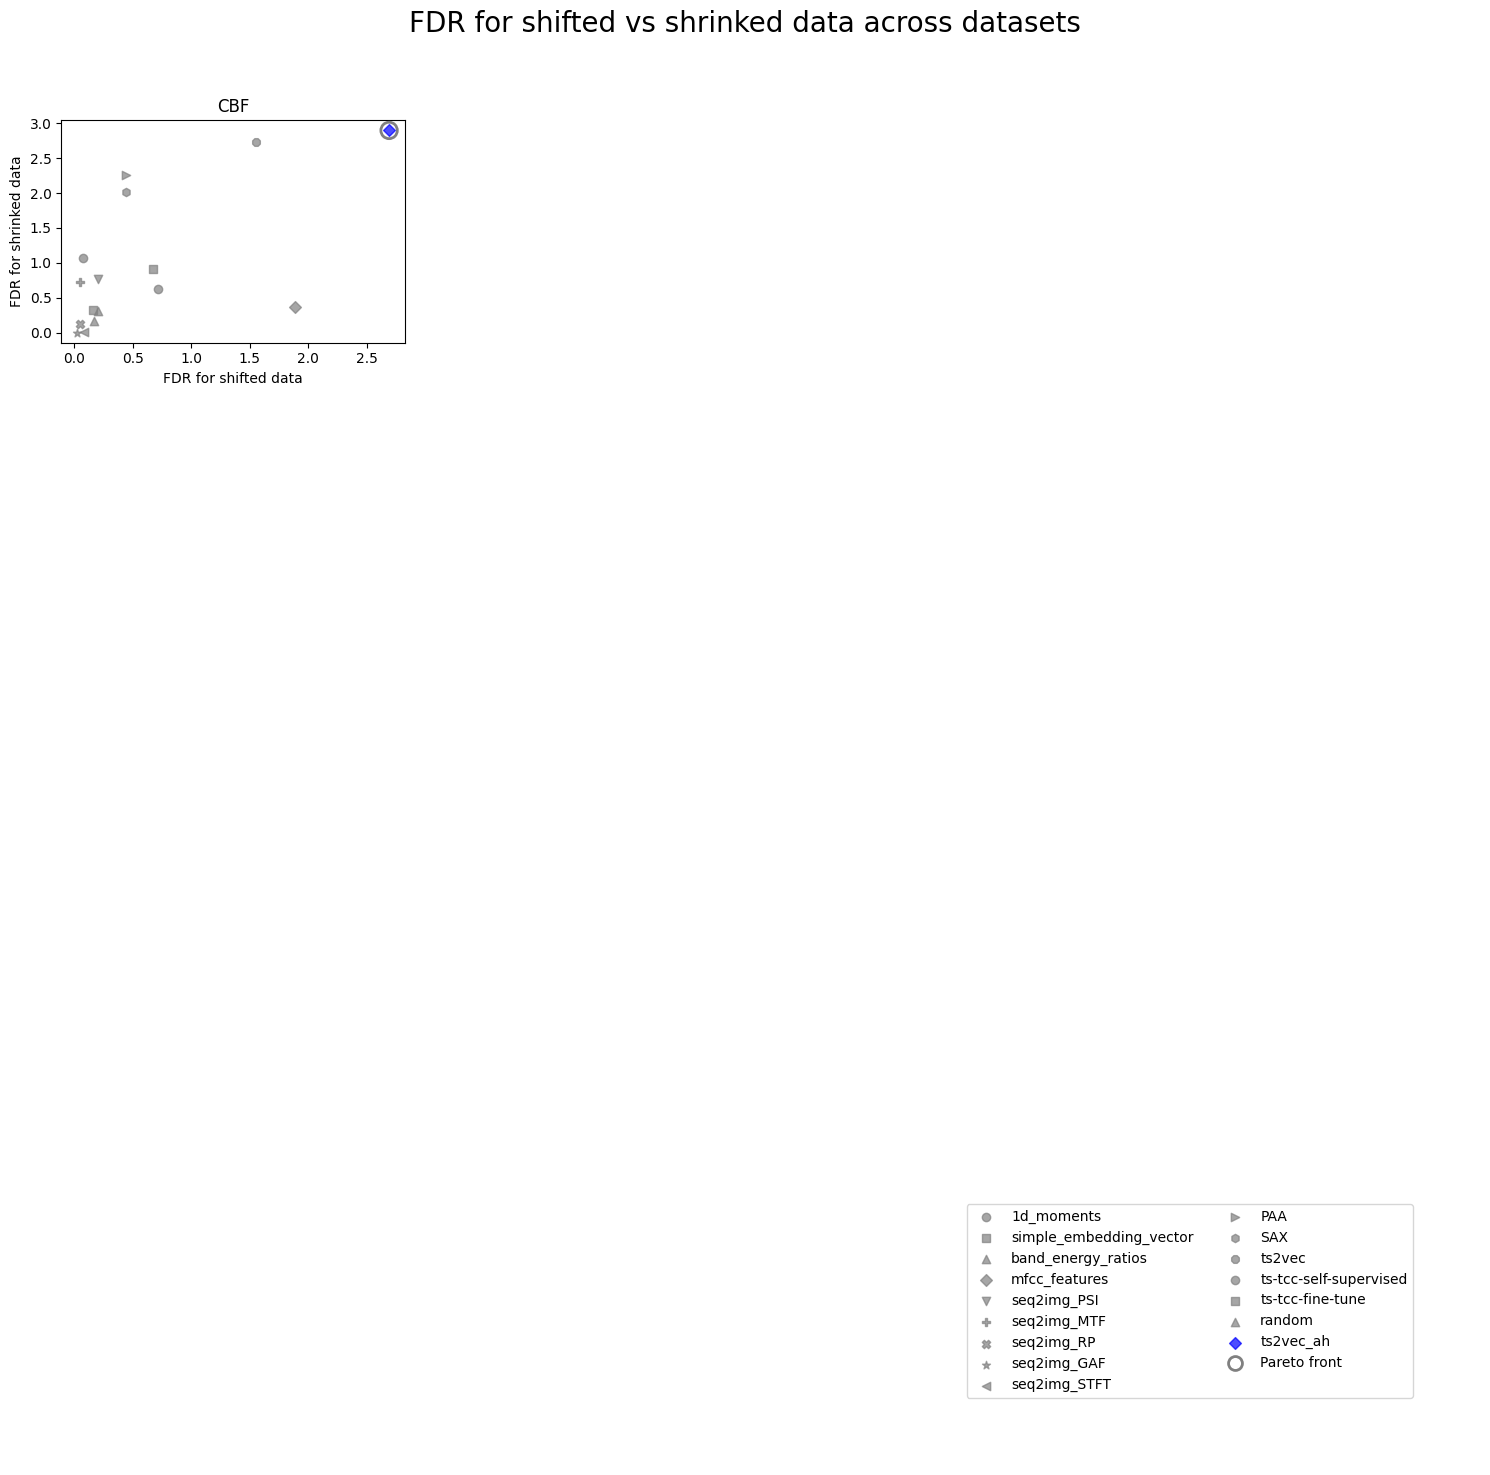

In [24]:
from matplotlib import pyplot as plt
import itertools
import numpy as np
from matplotlib.lines import Line2D

fig, axes = plt.subplots(5, 4, figsize=(15, 15))
axes = axes.flatten()

num_datasets = len(dataset_names)

markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', '<', '>', 'h', '8']
marker_cycle = itertools.cycle(markers)

color_cycle = itertools.cycle(['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan'])

def select_color(method):
    if method in new_methods:
        return next(color_cycle)
    else:
        return 'grey'

# Assign a marker to each method
method_markers = {method: next(marker_cycle) for method in fdr_shift.index}

# --- Pareto function (robust, maximization) ---
def pareto_front_max(xs, ys):
    xs = np.asarray(xs, dtype=float)
    ys = np.asarray(ys, dtype=float)
    n = len(xs)
    is_pareto = np.ones(n, dtype=bool)

    for i in range(n):
        for j in range(n):
            if i != j:
                if (xs[j] >= xs[i] and ys[j] >= ys[i]) and (xs[j] > xs[i] or ys[j] > ys[i]):
                    is_pareto[i] = False
                    break
    return is_pareto

for i, dataset_name in enumerate(dataset_names):

    # --- collect points FIRST (no change to your logic, just added) ---
    xs = []
    ys = []
    for method_name in fdr_shift.index:
        xs.append(fdr_shift.loc[method_name][dataset_name])
        ys.append(fdr_shrink.loc[method_name][dataset_name])

    xs = np.array(xs, dtype=float)
    ys = np.array(ys, dtype=float)

    pareto_mask = pareto_front_max(xs, ys)

    # --- your original loop (unchanged except index tracking) ---
    for j, method_name in enumerate(fdr_shift.index):
        x = xs[j]
        y = ys[j]

        x_jitter = x + np.random.normal(0, 0.0001, size=np.shape(x))
        y_jitter = y + np.random.normal(0, 0.0001, size=np.shape(y))

        axes[i].scatter(
            x_jitter,
            y_jitter,
            label=method_name,
            alpha=0.7,
            marker=method_markers[method_name],
            c=[select_color(method_name)]
        )

    # --- ADD: Pareto front overlay ---
    axes[i].scatter(
        xs[pareto_mask],
        ys[pareto_mask],
        s=140,
        facecolors='none',
        edgecolors='grey',
        linewidths=2,
        zorder=5
    )

    axes[i].set_xlabel("FDR for shifted data")
    axes[i].set_ylabel("FDR for shrinked data")
    axes[i].set_title(f"{dataset_name}")

# Hide any unused axes
for j in range(num_datasets, len(axes)):
    axes[j].axis('off')

# Single legend at bottom right
handles, labels = axes[0].get_legend_handles_labels()

pareto_handle = Line2D(
    [0], [0],
    marker='o',
    color='grey',
    markerfacecolor='none',
    linestyle='None',
    markersize=10,
    markeredgewidth=2,
    label='Pareto front'
)

handles.append(pareto_handle)
labels.append('Pareto front')

fig.legend(handles, labels,
           loc='lower right',
           bbox_to_anchor=(0.95, 0.05),
           ncol=2)

fig.suptitle("FDR for shifted vs shrinked data across datasets", y=0.98, fontsize=20)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("figures/fdr_shift_vs_shrink.png")
plt.show()